## 필수과제1
- 아래 주석  참고하여 데이터셋 생성 후 회귀와 같이 동일한 로직으로 기본모델과 튜닝모델 성능 비교 분석

In [2]:
# 분류 예제 데이터 생성
#X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42, n_informative=6)
#data = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
#data['Target'] = y

#분류모델은 xgb.XGBClassifier
#confusion_matrix
#피처중요도
#정확도
#성능이 개선되는 것을 비교 분석해 주세요!
#기본모델과 튜닝한 모델

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

# 회귀 예제 데이터 생성
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42, n_informative=6)
data = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(X.shape[1])])
data['Target'] = y


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#XGBOOST 불러오기
#기본모델 학습

basic_model = xgb.XGBRegressor(random_state=111)
basic_model.fit(X_train, y_train)

## 기본모델 예측 및 평가
y_pred_basic = basic_model.predict(X_test)
rmse_basic = mean_squared_error(y_test, y_pred_basic, squared=False)
r2_basic = r2_score(y_test, y_pred_basic)

print(f'베이직모델 RMSE {rmse_basic}')
print(f'베이직모델 r2_basic {r2_basic}')

# 하이퍼 파라미터 튜닝
# GridSearchCV

param_grid ={
    'n_estimators' :[50,100,200],
    'learning_rate':[0.01,0.1,0.3,0.5],
    'max_depth':[3,5,7,9],
    'subsample':[0.7, 1.0],
    'colsample_bytree':[0.7,1.0]    
}

tuned_model = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=111),
    param_grid= param_grid,
    scoring= 'neg_root_mean_squared_error',
    cv = 3    
)

tuned_model.fit(X_train, y_train)
print(tuned_model.best_params_) # 최적의 하이퍼파라미터

## 튜닝된 모델의 예측값 성능
y_pred_tuned=tuned_model.best_estimator_.predict(X_test)
rmse_tuned = mean_squared_error(y_test, y_pred_tuned, squared=False)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f'튜닝모델 RMSE {rmse_tuned}')
print(f'튜닝모델 r2_basic {r2_tuned}')

D:\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


베이직모델 RMSE 0.3115753971355355
베이직모델 r2_basic 0.6050077180341098
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}
튜닝모델 RMSE 0.2998011839914856
튜닝모델 r2_basic 0.6342966130700983


D:\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


<BarContainer object of 10 artists>

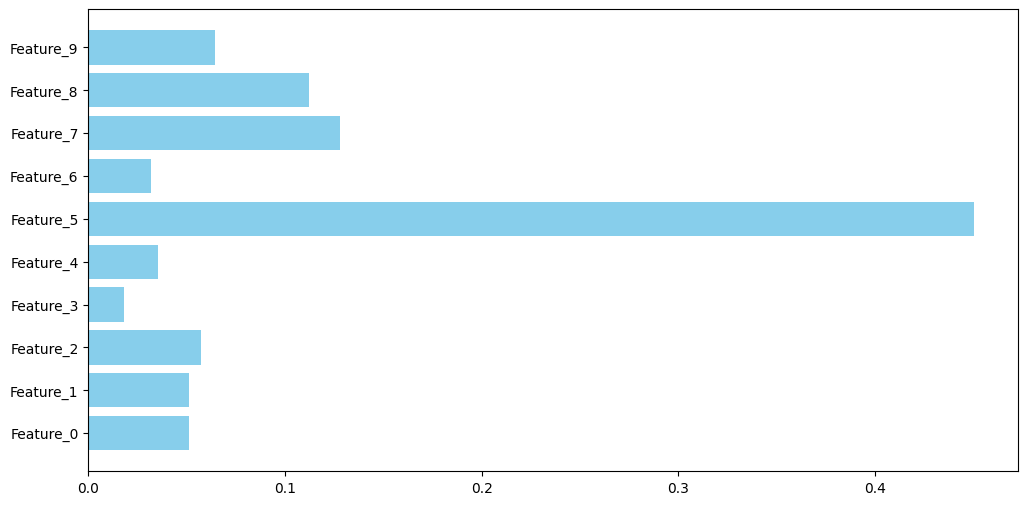

In [12]:
## 중요피처 시각화
## 피처에 대한 주요 시각화도 간단하게 추출할 수 있다.
importances=tuned_model.best_estimator_.feature_importances_
feature = [f'Feature_{i}' for i in range(X.shape[1])]
plt.figure(figsize=(12,6))
plt.barh(feature, importances, color= 'skyblue')